In [1]:
# IMPORTING THE LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from spacy import displacy
from spacy import tokenizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# set plot options
plt.rcParams['figure.figsize'] = (10,5)
default_plot_colour = '#00bfbf'

In [3]:
# LOADING THE DATA
news = pd.read_csv("fake_news_data.csv")

In [4]:
news.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [5]:
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


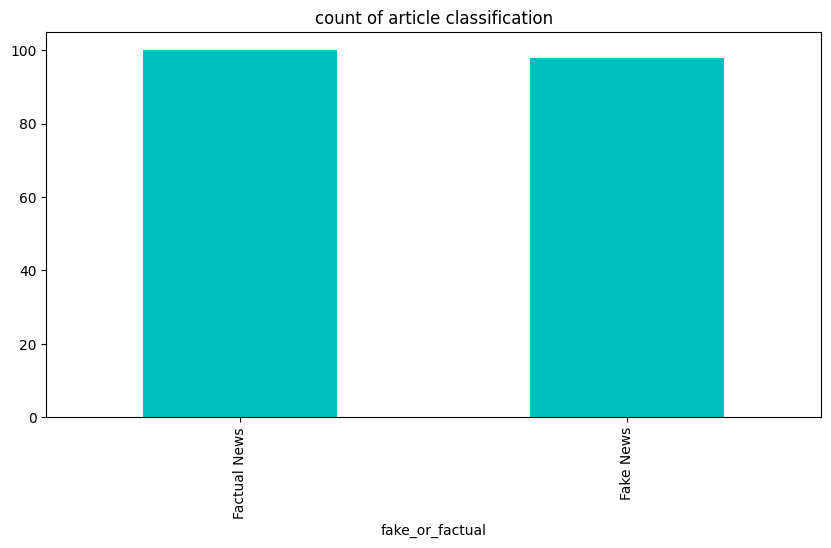

In [6]:
# PLOTTING COUNTS OF FAKE AND FACTS
news['fake_or_factual'].value_counts().plot(kind='bar', color=default_plot_colour)
plt.title("count of article classification")
plt.show()

POS TAGGING

In [7]:
nlp = spacy.load('en_core_web_sm')

In [8]:
# SEPERATING FACT AND FAKE NEWS
fake_news = news[news['fake_or_factual'] == 'Fake News']

fact_news = news[news['fake_or_factual'] == 'Factual News']

In [9]:
# CONVERTING INTO SPACYDOCS
fake_spacydocs = list(nlp.pipe(fake_news['text']))
fact_spacydocs = list(nlp.pipe(fact_news['text']))

In [10]:
# CREATING A FUNCTION TO RETURN PART OF SPEECH AND NAMED ENTITY
def extract_token_tags(doc:spacy.tokens.doc.Doc):
        return[(i.text, i.ent_type_, i.pos_) for i in doc]

In [11]:
fake_tagsdf = []
columns = ['token', 'ner_tag', 'pos_tag']

In [12]:
# USING FOR LOOP TO FILL THE FAKE TAGS DF
for ix, doc in enumerate(fake_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fake_tagsdf.append(tags)

In [13]:
fake_tagsdf = pd.concat(fake_tagsdf)

In [14]:
fact_tagsdf = []

In [15]:
# USING FOR LOOP TO FILL THE FACTS TAGS DF
for ix, doc in enumerate(fact_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fact_tagsdf.append(tags)

In [16]:
fact_tagsdf = pd.concat(fact_tagsdf)

In [17]:
fake_tagsdf

,token,ner_tag,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN
...,...,...,...
743,.,,PUNCT
744,Via,,PROPN
745,:,,PUNCT
746,Campus,PERSON,PROPN


In [18]:
fact_tagsdf

,token,ner_tag,pos_tag
0,WASHINGTON,GPE,PROPN
1,(,,PUNCT
2,Reuters,ORG,PROPN
3,),,PUNCT
4,-,,PUNCT
...,...,...,...
85,citing,,VERB
86,three,CARDINAL,NUM
87,unnamed,,ADJ
88,officials,,NOUN


In [19]:
# CHECKING THE PART OF SPEECH TAGS FOR THE FAKE NEWS
fake_pos = fake_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)
print(fake_pos)

              token pos_tag  counts
29                ,   PUNCT    1908
7451            the     DET    1834
41                .   PUNCT    1530
5766             of     ADP     922
2665            and   CCONJ     875
...             ...     ...     ...
3770     detectives    VERB       1
3769      detective    NOUN       1
3768       detained    VERB       1
3766         detail    NOUN       1
4014  election.-Two     NUM       1

[8029 rows x 3 columns]


In [20]:
# CHECKING THE PART OF SPEECH TAGS FOR FACT NEWS
fact_pos = fact_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)
print(fact_pos)

         token pos_tag  counts
6145       the     DET    1903
14           ,   PUNCT    1698
21           .   PUNCT    1382
4716        of     ADP     884
1898         a     DET     789
...        ...     ...     ...
2909  crossing    VERB       1
2911   crucial     ADJ       1
2913    cruise    NOUN       1
2914   crusade    NOUN       1
6653         …   PUNCT       1

[6654 rows x 3 columns]


In [21]:
# CHECKING THE COUNT OF EACH POS TAG FOR FAKE NEWS
fake_pos_count = fake_pos.groupby(['pos_tag'])['token'].count().sort_values(ascending=False)
print(fake_pos_count)

pos_tag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
DET        42
INTJ       24
PUNCT      23
CCONJ      19
X          14
PART       10
SYM         5
SPACE       3
Name: token, dtype: int64


In [22]:
# CHECKING THE COUNT OF EACH POS TAG FOR FACT NEWS
fact_pos_count = fact_pos.groupby(['pos_tag'])['token'].count().sort_values(ascending=False)
print(fact_pos_count)

pos_tag
NOUN     2179
VERB     1539
PROPN    1379
ADJ       747
ADV       263
NUM       205
PRON       79
ADP        70
AUX        43
SCONJ      42
DET        36
PUNCT      22
SPACE      11
CCONJ      11
X          10
INTJ        7
PART        7
SYM         4
Name: token, dtype: int64


In [23]:
# CHECKING THE COUNT OF EACH NOUN
nouns = fake_pos[fake_pos.pos_tag == 'NOUN']
print(nouns)

              token pos_tag  counts
5981         people    NOUN      77
7349              t    NOUN      65
6216      president    NOUN      58
7960          women    NOUN      55
7516           time    NOUN      52
...             ...     ...     ...
3781   developments    NOUN       1
3778    devastation    NOUN       1
3772  determination    NOUN       1
3769      detective    NOUN       1
3766         detail    NOUN       1

[2586 rows x 3 columns]


NAMED ENTITIES

In [24]:
# THE TOP NAMED ENTITIES
top_entities_fake = fake_tagsdf[fake_tagsdf['ner_tag'] != ""].groupby(['token', 'ner_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)
print(top_entities_fake)

          token ner_tag  counts
1730      Trump  PERSON     154
1729      Trump     ORG     152
2129        the     ORG     121
592     Clinton  PERSON     118
718      Donald  PERSON      75
...         ...     ...     ...
886   Hempstead     GPE       1
885      Helbig  PERSON       1
884       Hedge  PERSON       1
883     Heather  PERSON       1
1085       Left     ORG       1

[2170 rows x 3 columns]


In [25]:
top_entities_fact = fact_tagsdf[fact_tagsdf['ner_tag'] != ""].groupby(['token', 'ner_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)
print(top_entities_fact)

           token ner_tag  counts
1968         the     ORG     159
1633        U.S.     GPE     138
1373     Reuters     ORG     131
1615       Trump  PERSON     125
1614       Trump     ORG     124
...          ...     ...     ...
804       German    NORP       1
803      Georgia     GPE       1
801       George     ORG       1
800   Geological     ORG       1
1003      Kander  PERSON       1

[2007 rows x 3 columns]


In [26]:
# creating custom palette to ensure plots are consistent
ner_palette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'NORP': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6]
}

[Text(0.5, 1.0, 'Most Common Entities in Fake News')]

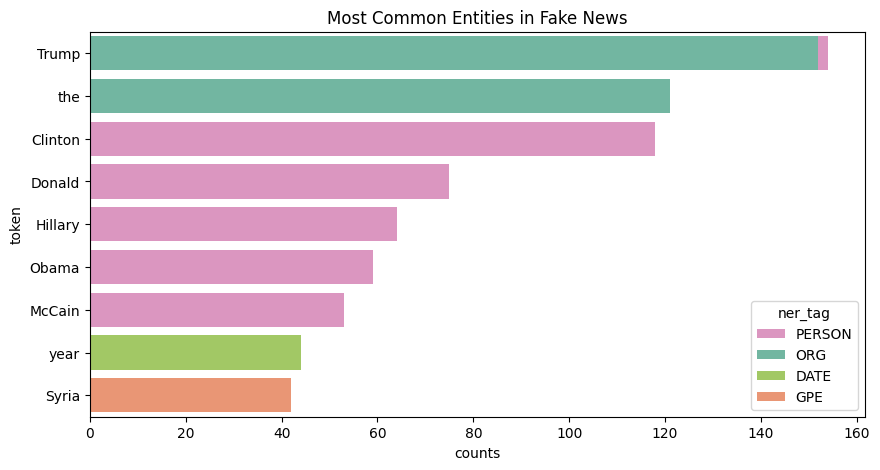

In [27]:
# PLOT TO SHOW MOST COMMON ENTITIES IN FAKE NEWS
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fake[0:10],
    orient = 'h',
    dodge=False
).set(title='Most Common Entities in Fake News')

[Text(0.5, 1.0, 'Most Common Entities in Factual News')]

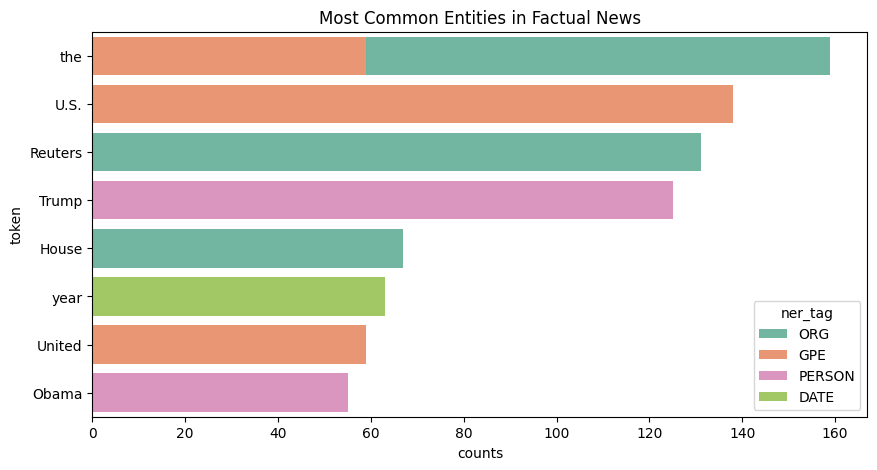

In [28]:
# PLOT TO SHOW MOST NAMED ENTITIES IN FACT NEWS
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fact[0:10],
    orient = 'h',
    dodge=False
).set(title='Most Common Entities in Factual News')

TEXT PREPROCESSING

In [29]:
news.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [30]:
# REMOVING THE LINES WITH LOCATION AND HYPHEN
news['news_cleaned'] = news.apply(lambda x: re.sub(r"^[^-]*-\s", "", x['text']), axis=1)

In [31]:
# CONVERTING TO LOWER STRING
news['news_cleaned'] = news['news_cleaned'].str.lower()

In [32]:
# REMOVING THE PUNCTUATIONS
news['news_cleaned'] = news.apply(lambda x: re.sub(r"([^\w\s])", "", x['news_cleaned']), axis=1)

In [33]:
en_stopwords = stopwords.words('english')

In [34]:
# REMOVING STOPWORDS
news['news_cleaned'] = news['news_cleaned'].apply(lambda x: ' '.join([word for word in x.split() if word not in (en_stopwords)]))

In [35]:
# TOKENIZING THE TEXT
news['news_cleaned'] = news.apply(lambda x: x['news_cleaned'].split(), axis=1)

In [37]:
# LEMMATIZING THE TEXTS
lemmatizer = WordNetLemmatizer()

news['news_cleaned'] = news['news_cleaned'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [38]:
news.head()

,title,text,date,fake_or_factual,news_cleaned
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,..."


In [39]:
# PASSING ALL INTO AN EMPTY LIST
clean_tokens = sum(news['news_cleaned'], [])

In [42]:
unigrams = (pd.Series(nltk.ngrams(clean_tokens,1)).value_counts())
print(unigrams)

(said,)            580
(trump,)           580
(u,)               277
(state,)           275
(president,)       259
                  ... 
(competing,)         1
(materialized,)      1
(unbacked,)          1
(uprising,)          1
(petrosyan,)         1
Name: count, Length: 9067, dtype: int64


In [43]:
bigrams = (pd.Series(nltk.ngrams(clean_tokens,2)).value_counts())
print(bigrams)

(donald, trump)           113
(united, state)            84
(white, house)             74
(president, donald)        47
(hillary, clinton)         39
                         ... 
(extremely, concerned)      1
(trump, extremely)          1
(wednesday, president)      1
(software, white)           1
(campus, reform)            1
Name: count, Length: 36971, dtype: int64


In [44]:
trigrams = (pd.Series(nltk.ngrams(clean_tokens,3)).value_counts())
print(trigrams)

(president, donald, trump)       46
(president, barack, obama)       14
(new, york, time)                11
(u, president, donald)           10
(white, house, official)         10
                                 ..
(according, new, york)            1
(york, time, ethical)             1
(time, ethical, handbook)         1
(ethical, handbook, employee)     1
(via, campus, reform)             1
Name: count, Length: 41238, dtype: int64


SENTIMENT ANALYSIS

In [45]:
vader_sentiment = SentimentIntensityAnalyzer()

In [46]:
# CREATING A NEW COLUMN FOR THE SENTIMENT SCORE
news['vader_sentiment_score'] = news['text'].apply(lambda x: vader_sentiment.polarity_scores(x)['compound'])

In [47]:
news.head()

,title,text,date,fake_or_factual,news_cleaned,vader_sentiment_score
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590


In [49]:
bins = [-1,-0.1,0.1,1]
names = ['negative', 'neutral', 'positive']

In [50]:
# CREATING LABELS FOR THE SENTIMENT SCORE
news['vader_sentiment_label'] = pd.cut(news['vader_sentiment_score'], bins=bins, labels=names)

In [51]:
news.head()

,title,text,date,fake_or_factual,news_cleaned,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,positive


<Axes: xlabel='vader_sentiment_label'>

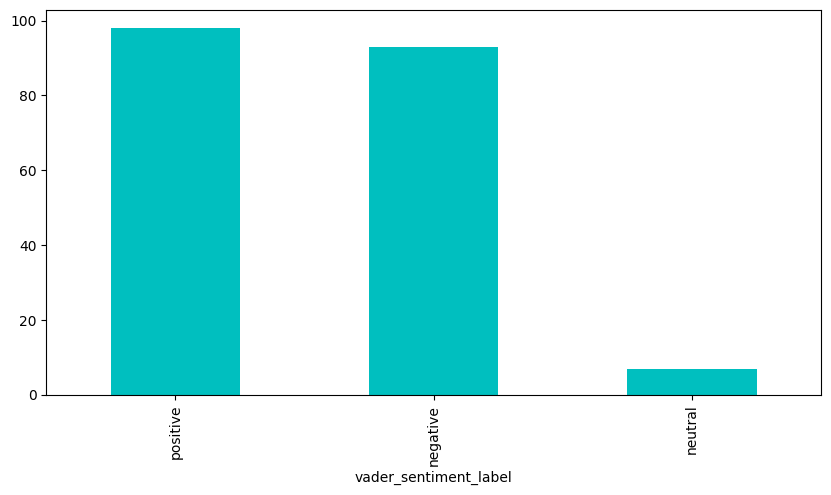

In [53]:
# PLOT TO SHOW THE COUNTS OF EACH SENTIMENT LABEL
news['vader_sentiment_label'].value_counts().plot.bar(color=default_plot_colour)

C:\Users\USER\AppData\Local\Temp\ipykernel_1884\3461837329.py:1: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment by News Type')]

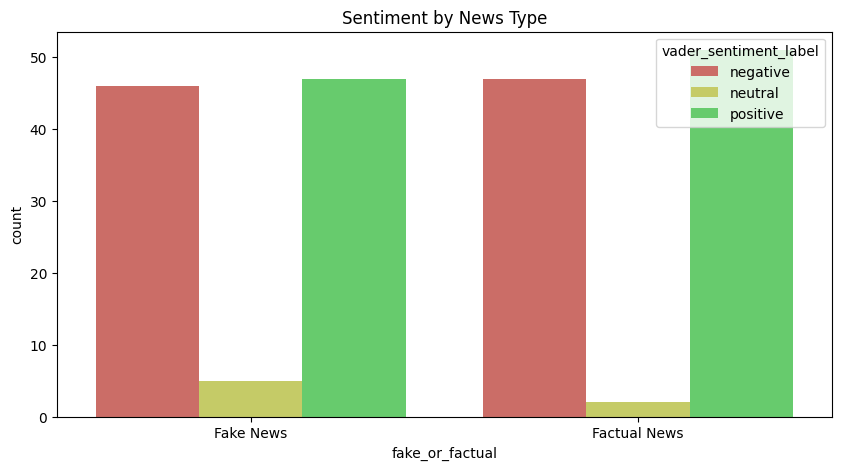

In [60]:
# PLOT TO SHOW LABEL COUNTS FOR EACH TYPE OF NEWS
sns.countplot(
    x = 'fake_or_factual',
    hue = 'vader_sentiment_label',
    palette = sns.color_palette("hls"),
    data = news
).set(title = 'Sentiment by News Type')

TOPIC MODELLING

In [61]:
# SEPARATING FAKE NEWS
fake_news_text = news[news['fake_or_factual'] == 'Fake News']['news_cleaned'].reset_index(drop=True)

In [63]:
# CREATING DICTIONARY FOR OUR FAKE NEWS
dictionary_fake = corpora.Dictionary(fake_news_text)

In [64]:
# CREATING THE DOC TERM MATRIX
doc_term_fake = [dictionary_fake.doc2bow(text) for text in fake_news_text]

In [69]:
# CREATING THE MODEL AND GETTING COHERENCE VALUES
coherence_values = []
model_list = []

min_topics = 2
max_topics = 11

for num_topics_i in range(min_topics, max_topics+1):
    model = gensim.models.LdaModel(doc_term_fake, num_topics=num_topics_i, id2word=dictionary_fake)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=fake_news_text, dictionary=dictionary_fake, coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())

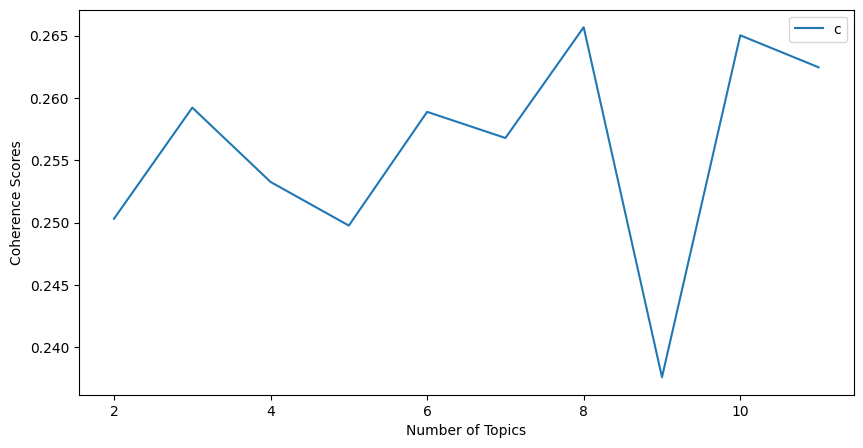

In [70]:
# PLOT TO HELP PICK OPTIMAL NUMBER OF TOPICS
plt.plot(range(min_topics, max_topics+1), coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Scores")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [71]:
# TRAINING THE LDA MODEL
num_topics_lda = 8
lda_model = gensim.models.LdaModel(corpus=doc_term_fake, id2word=dictionary_fake, num_topics = num_topics_lda)

In [73]:
lda_model.print_topics(num_topics=num_topics_lda, num_words=5)

[(0,
  '0.008*"trump" + 0.007*"clinton" + 0.006*"said" + 0.006*"president" + 0.004*"one"'),
 (1,
  '0.023*"trump" + 0.006*"state" + 0.005*"said" + 0.004*"time" + 0.004*"donald"'),
 (2,
  '0.009*"trump" + 0.005*"president" + 0.005*"state" + 0.004*"clinton" + 0.004*"u"'),
 (3,
  '0.007*"trump" + 0.005*"president" + 0.004*"said" + 0.004*"hillary" + 0.003*"million"'),
 (4,
  '0.004*"said" + 0.004*"trump" + 0.004*"food" + 0.003*"clinton" + 0.003*"one"'),
 (5,
  '0.012*"trump" + 0.006*"president" + 0.005*"said" + 0.005*"republican" + 0.004*"time"'),
 (6,
  '0.014*"trump" + 0.004*"state" + 0.004*"one" + 0.004*"clinton" + 0.004*"know"'),
 (7,
  '0.006*"trump" + 0.005*"said" + 0.004*"u" + 0.003*"state" + 0.003*"president"')]

In [77]:
def tfidf_corpus(doc_term_matrix):
    tfidf = TfidfModel(corpus=doc_term_matrix, normalize=True)
    corpus_tfidf = tfidf[doc_term_matrix]
    return corpus_tfidf

In [81]:
def get_coherence_scores(corpus, dictionary, text, min_topics, max_topics):
    coherence_values = []
    model_list = []
    for num_topics_i in range(min_topics, max_topics+1):
        model = LsiModel(corpus, num_topics = num_topics_i, id2word = dictionary)
        model_list.append(model)
        coherence_model = CoherenceModel(model=model, texts=text, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherence_model.get_coherence())

    plt.plot(range(min_topics, max_topics+1), coherence_values)
    plt.xlabel('number of topics')
    plt.ylabel('coherent scores')
    plt.legend("coherence_values", loc='best')
    plt.show()

In [82]:
corpus_tfidf_fake = tfidf_corpus(doc_term_fake)

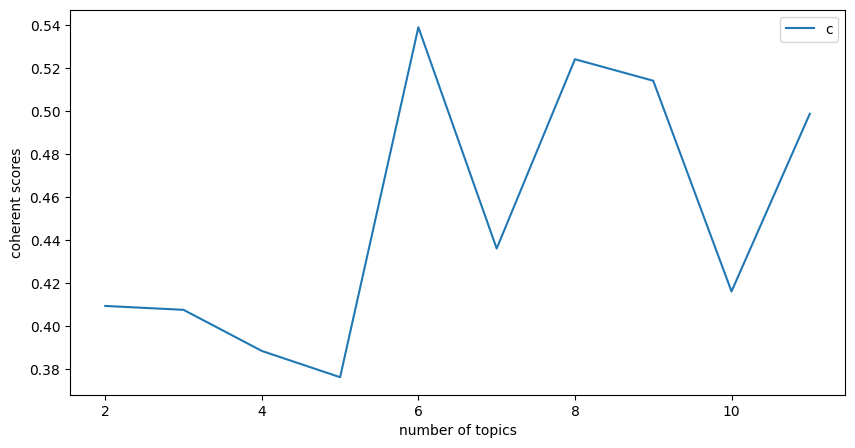

In [83]:
get_coherence_scores(corpus_tfidf_fake, dictionary_fake, fake_news_text, min_topics=2, max_topics=11)

In [86]:
# TRAINING LSI MODEL
lsa_model = LsiModel(corpus_tfidf_fake, id2word=dictionary_fake, num_topics=6)

In [87]:
lsa_model.print_topics()

[(0,
  '0.190*"trump" + 0.136*"clinton" + 0.095*"hillary" + 0.094*"obama" + 0.089*"president" + 0.087*"woman" + 0.078*"republican" + 0.078*"party" + 0.077*"flynn" + 0.074*"candidate"'),
 (1,
  '0.325*"boiler" + 0.284*"acr" + 0.244*"room" + 0.240*"pm" + 0.186*"broadcast" + 0.180*"radio" + 0.142*"animal" + 0.142*"tune" + 0.134*"jay" + 0.132*"episode"'),
 (2,
  '0.623*"flynn" + 0.182*"immunity" + 0.122*"nana" + 0.116*"mr" + 0.110*"30" + 0.108*"march" + 0.102*"russian" + 0.100*"source" + -0.095*"school" + 0.092*"adviser"'),
 (3,
  '-0.217*"clinton" + 0.185*"school" + 0.175*"student" + -0.142*"hillary" + 0.122*"flynn" + 0.121*"county" + -0.110*"sander" + -0.098*"debate" + -0.097*"woman" + -0.091*"nominee"'),
 (4,
  '-0.200*"email" + 0.196*"trump" + -0.168*"dnc" + 0.141*"flynn" + -0.124*"clinton" + -0.111*"department" + 0.111*"cruz" + -0.110*"rich" + -0.103*"wikileaks" + -0.099*"sander"'),
 (5,
  '-0.277*"student" + -0.161*"school" + -0.158*"conference" + -0.135*"trump" + 0.125*"mccain" + 0.

SPLITTING THE DATA

In [89]:
# CHOOSING FEATURES AND TARGETS
X = [','.join(map(str, i)) for i in news['news_cleaned']]

Y = news['fake_or_factual']

In [90]:
# PASSING IN THE VECTORIZER
countvec = CountVectorizer()

In [91]:
X_vectorized = countvec.fit_transform(X)

In [95]:
# CREATIN BAG OF WORDS
bag_of_words =pd.DataFrame(X_vectorized.toarray(), columns=countvec.get_feature_names_out())

In [96]:

X_train, X_test, Y_train, Y_test = train_test_split(bag_of_words, Y, test_size=0.3, random_state=3)

TRAINING THE MODEL

In [97]:
classifier = LogisticRegression()

In [98]:
classifier.fit(X_train, Y_train)

LogisticRegression()

In [101]:
test_prediction = classifier.predict(X_test)

MODEL EVALUATION

In [102]:
accuracy_score(test_prediction, Y_test)

0.9

In [103]:
print(classification_report(Y_test, test_prediction))

              precision    recall  f1-score   support

Factual News       0.80      1.00      0.89        24
   Fake News       1.00      0.83      0.91        36

    accuracy                           0.90        60
   macro avg       0.90      0.92      0.90        60
weighted avg       0.92      0.90      0.90        60



In [104]:
# USING THE SVM MODEL
svm = SGDClassifier()

In [105]:
svm.fit(X_train, Y_train)

SGDClassifier()

In [106]:
test_prediction = svm.predict(X_test)

In [108]:
accuracy_score(test_prediction, Y_test)

0.8666666666666667

In [110]:
print(classification_report(Y_test, test_prediction))

              precision    recall  f1-score   support

Factual News       0.77      0.96      0.85        24
   Fake News       0.97      0.81      0.88        36

    accuracy                           0.87        60
   macro avg       0.87      0.88      0.87        60
weighted avg       0.89      0.87      0.87        60

